# Reading and visualising a mesh with meshio++

This notebook reads the bundled `example.msh` (a Gmsh 4.1 mesh of a
mechanical bracket, ~52k nodes / ~298k elements) with **meshio++**
(`meshioplusplus`) and renders it with **PyVista**.

PyVista's `from_meshio` targets the original `meshio` package, so here we
go through the format layer instead: meshio++ writes a temporary `.vtu`
and PyVista reads it back with its native (VTK) reader — no dependency on
the original `meshio`.

In [1]:
import os
import tempfile
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

import meshioplusplus as mp

# Head-less, static rendering (no display / live server needed).
pv.OFF_SCREEN = True
pv.set_jupyter_backend('static')

EXAMPLE = os.path.join(os.path.dirname(os.getcwd()), 'example.msh')
if not os.path.exists(EXAMPLE):
    EXAMPLE = os.path.join('..', 'example.msh')  # when run from example/python/ with a different cwd
print('mesh file:', EXAMPLE)

mesh file: /home/vicente/src/meshioplusplus/example/example.msh


In [2]:
def to_pyvista(mesh):
    """meshio++ Mesh -> pyvista.UnstructuredGrid via a temporary .vtu."""
    with tempfile.NamedTemporaryFile(suffix='.vtu', delete=False) as f:
        tmp = f.name
    try:
        mesh.write(tmp, binary=True)
        return pv.read(tmp)
    finally:
        os.unlink(tmp)


def show(img, title=None, figsize=(9, 6)):
    """Embed a rendered RGB screenshot as a static image."""
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis('off')
    if title:
        plt.title(title)
    plt.tight_layout()
    plt.show()

## Read the mesh

In [3]:
mesh = mp.read(EXAMPLE)

totals = Counter()
for cb in mesh.cells:
    totals[cb.type] += len(cb.data)

print(f'points      : {len(mesh.points):,}')
print(f'cell blocks : {len(mesh.cells):,}')
print('cell totals :')
for t, n in sorted(totals.items(), key=lambda kv: -kv[1]):
    print(f'    {t:10s} {n:>8,}')

lo = mesh.points.min(axis=0)
hi = mesh.points.max(axis=0)
print('bounding box:', np.round(lo, 2), '->', np.round(hi, 2))

points      : 52,282
cell blocks : 710
cell totals :
    tetra       235,014
    triangle     58,394
    line          4,169
    vertex          234
bounding box: [-3.5  -3.18  0.  ] -> [0.   0.62 0.38]


## Visualise the full part

We convert to a PyVista grid and render an isometric view with the mesh
edges drawn on the surface.

UnstructuredGrid (0x7ffa4d653100)
  N Cells:    297811
  N Points:   52282
  X Bounds:   -3.505e+00, 0.000e+00
  Y Bounds:   -3.185e+00, 6.250e-01
  Z Bounds:   0.000e+00, 3.820e-01
  N Arrays:   2


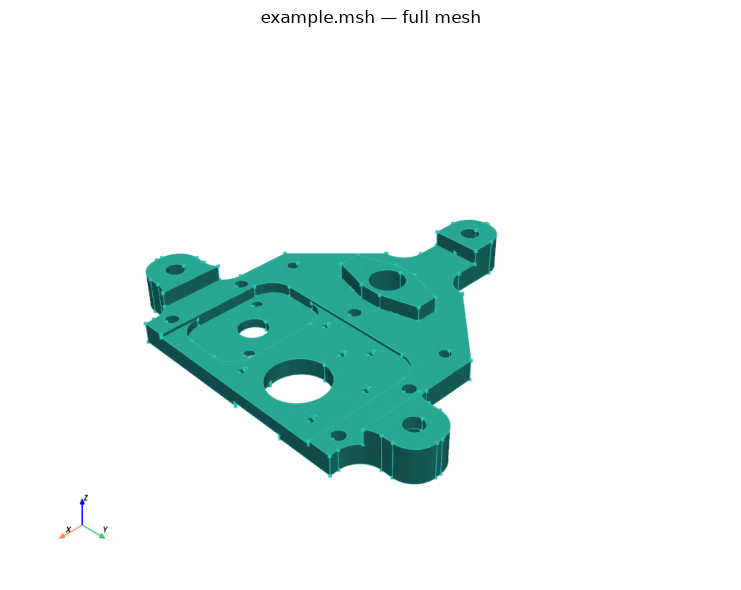

In [4]:
grid = to_pyvista(mesh)
print(grid)

try:
    pl = pv.Plotter(off_screen=True, window_size=(1000, 760))
    pl.add_mesh(grid, color='#2ec4b6', show_edges=True, edge_color='#1f4e79',
                line_width=0.3)
    pl.camera_position = 'iso'
    pl.add_axes()
    img = pl.screenshot(return_img=True)
    pl.close()
    show(img, 'example.msh — full mesh')
except Exception as exc:  # pragma: no cover - head-less GL fallback
    print('PyVista render failed, falling back to matplotlib:', exc)
    surf = np.concatenate([cb.data for cb in mesh.cells if cb.type == 'triangle'])
    fig = plt.figure(figsize=(9, 6))
    ax = fig.add_subplot(111, projection='3d')
    p = mesh.points
    ax.plot_trisurf(p[:, 0], p[:, 1], p[:, 2], triangles=surf,
                    color='#2ec4b6', edgecolor='none')
    plt.tight_layout(); plt.show()

## Clip to reveal the interior

The part is a solid tetrahedral mesh. Clipping with a plane exposes the
interior elements.

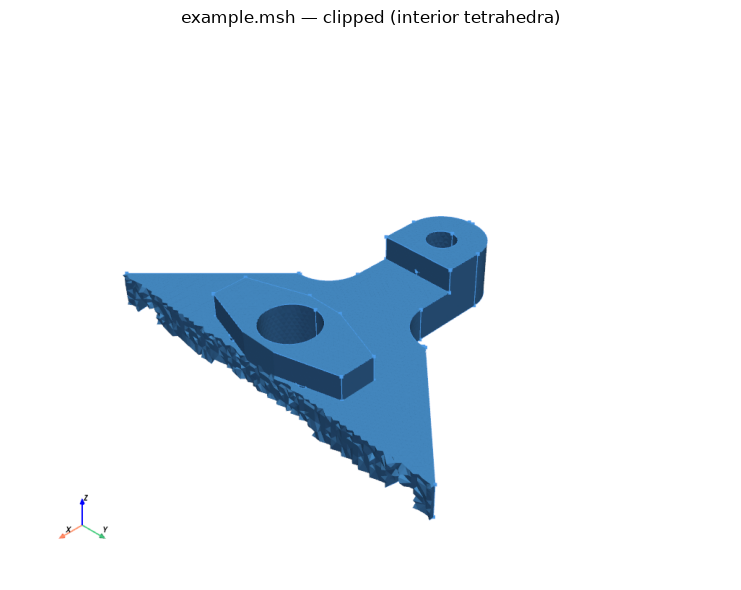

In [5]:
try:
    clipped = grid.clip('x', crinkle=True)
    pl = pv.Plotter(off_screen=True, window_size=(1000, 760))
    pl.add_mesh(clipped, scalars=None, color='#4c9be8', show_edges=True,
                edge_color='#1f4e79', line_width=0.3)
    pl.camera_position = 'iso'
    pl.add_axes()
    img = pl.screenshot(return_img=True)
    pl.close()
    show(img, 'example.msh — clipped (interior tetrahedra)')
except Exception as exc:  # pragma: no cover
    print('Clip/render skipped:', exc)

## Vector figures coloured by a field

The renders above are rasters. meshio++ can also write the mesh as a
**vector** figure — SVG or TikZ — with each face coloured by a data
array, which is what you want for a paper or a slide: it stays sharp at
any zoom, and it needs no plotting library at all (the colormaps are
built into the core).

We colour by element quality. `attach_quality` writes each metric back as
`cell_data`, and because the writer projects the mesh's *skin*, it tracks
each boundary facet back to the volume cell that owns it — so the value
you see on a facet really is that element's.

The bracket is cropped first: its full skin is ~58k facets, which makes a
4.5 MB SVG whose individual elements are smaller than a pixel.

quality.svg: 93 KiB, 1118 facets


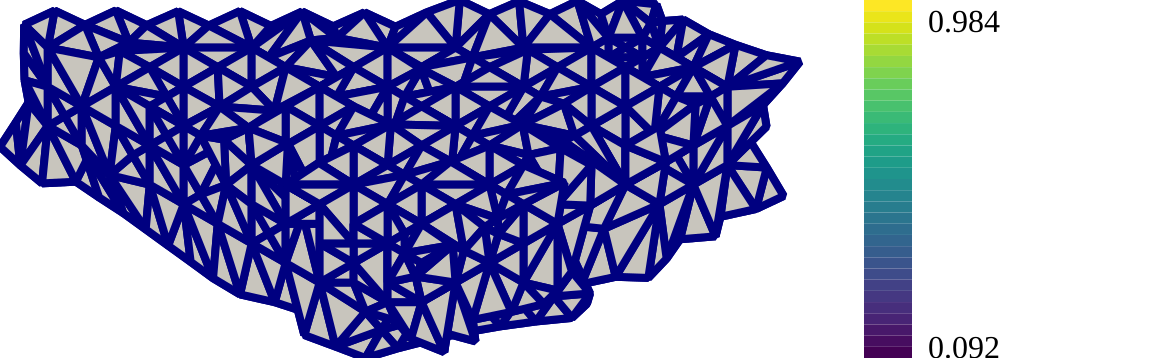

In [6]:
import pathlib

from IPython.display import SVG, display

# A legible corner of the part: the whole skin is far too fine for a figure.
bare = mp.Mesh(mesh.points, mesh.cells)
lo, hi = bare.points.min(axis=0), bare.points.max(axis=0)
corner = mp.crop(bare, bbox=[*lo, *(lo + (hi - lo) * 0.4)])
corner = mp.Mesh(corner.points, [b for b in corner.cells if len(b.data)])

annotated = mp.attach_quality(corner)
out = pathlib.Path(tempfile.mkdtemp()) / 'quality.svg'
mp.write(
    out,
    annotated,
    color_by='quality:scaled_jacobian',  # any point_data / cell_data name
    cmap='viridis',                      # viridis / coolwarm / turbo
    colorbar=True,
    image_width=800,
)
print(f'{out.name}: {out.stat().st_size / 1024:.0f} KiB, '
      f'{sum(len(b.data) for b in mp.extract_skin(corner, linearize=True).cells)} facets')
display(SVG(filename=str(out)))

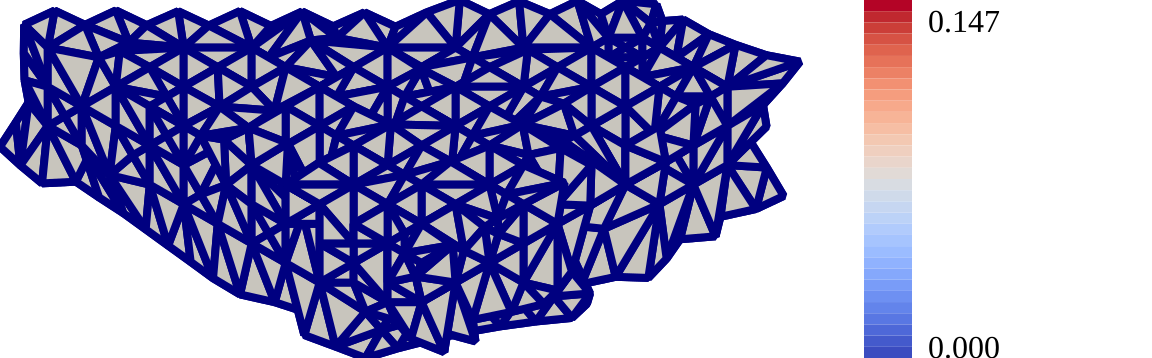

In [7]:
# Point data works too, averaged over each face's corners -- and a diverging
# colormap suits a signed quantity better than a sequential one.
height = mp.Mesh(corner.points, corner.cells,
                 point_data={'z': corner.points[:, 2]})
out2 = out.parent / 'height.svg'
mp.write(out2, height, color_by='z', cmap='coolwarm', colorbar=True,
         image_width=800)
display(SVG(filename=str(out2)))

The same options are available on the command line —
`meshioplusplus convert mesh.vtu figure.svg --color-by NAME --colorbar` —
and from the TikZ writer, which emits the identical figure as LaTeX.

That's the round trip: **meshio++ reads the Gmsh file**, hands the mesh to
PyVista through a VTU round-trip, and PyVista renders it. See
[`02_convert_and_inspect.ipynb`](./02_convert_and_inspect.ipynb) for
converting the same mesh between formats.